In [2]:
import kagglehub
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD # TruncatedSVD is LSA
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from wordcloud import WordCloud


# Downloads
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('universal_tagset')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/konstantinhanemann/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/konstantinhanemann/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/konstantinhanemann/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/konstantinhanemann/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/konstantinhanemann/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/konstantinhanemann/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

In [3]:
# Load Dataset
path = kagglehub.dataset_download("goyaladi/twitter-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_full = pd.read_csv(os.path.join(path, csv_file))

# Sample rows
df = df_full.sample(n=10000, random_state=42).reset_index(drop=True)
print(f"Dataset loaded. Columns: {df.columns.tolist()}")
df.head(3)

Dataset loaded. Columns: ['Tweet_ID', 'Username', 'Text', 'Retweets', 'Likes', 'Timestamp']


,Tweet_ID,Username,Text,Retweets,Likes,Timestamp
0,6253,timothywilliams,Just specific color. Hour federal open act. Pa...,94,39,2023-05-11 02:24:49
1,4685,gjordan,Move memory join.\nIndeed model quite adult wh...,12,100,2023-04-20 13:07:46
2,1732,michaellowery,Meeting recently bed force after difference.\n...,40,68,2023-03-15 23:23:37


In [4]:
# 1. Show first lines
print("--- FIRST ROWS ---")
print(df.head())

--- FIRST ROWS ---
   Tweet_ID         Username  \
0      6253  timothywilliams   
1      4685          gjordan   
2      1732    michaellowery   
3      4743     murphysharon   
4      4522    sarahtownsend   

                                                Text  Retweets  Likes  \
0  Just specific color. Hour federal open act. Pa...        94     39   
1  Move memory join.\nIndeed model quite adult wh...        12    100   
2  Meeting recently bed force after difference.\n...        40     68   
3  Clear friend phone card arm continue. Five amo...        50     47   
4  Experience alone figure ever marriage major ra...        65     46   

             Timestamp  
0  2023-05-11 02:24:49  
1  2023-04-20 13:07:46  
2  2023-03-15 23:23:37  
3  2023-05-03 18:37:31  
4  2023-03-04 07:57:46  


In [5]:
# 2. Find structure and data types
print("\n--- DATA INFO ---")
print(df.info())


--- DATA INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   10000 non-null  int64
 1   Username   10000 non-null  str  
 2   Text       10000 non-null  str  
 3   Retweets   10000 non-null  int64
 4   Likes      10000 non-null  int64
 5   Timestamp  10000 non-null  str  
dtypes: int64(3), str(3)
memory usage: 468.9 KB
None


In [6]:
# 3. Identify column names
print("\n--- COLUMNS ---")
print(df.columns)


--- COLUMNS ---
Index(['Tweet_ID', 'Username', 'Text', 'Retweets', 'Likes', 'Timestamp'], dtype='str')


In [7]:
# 4. Check for missing values
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())


--- MISSING VALUES ---
Tweet_ID     0
Username     0
Text         0
Retweets     0
Likes        0
Timestamp    0
dtype: int64


In [8]:
# 5. Cleaning
def clean_pipeline_nouns(text):
    # 1. Basic Cleaning
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 2. Initial Tokenization
    raw_tokens = text.split()
    
    # 3. Custom Stop Words (Removing Twitter-specific noise)
    custom_stops = {'rt', 'amp', 'get', 'know', 'one', 'would', 'like', 'tweet', 'twitter', 
                    'people', 'day', 'thing', 'time', 'year', 'way', 'life', 'world', 'man', 'woman', 'today'}
    stop_words = set(stopwords.words('english')).union(custom_stops)
    
    # 4. POS Tagging
    # We use the 'universal' tagset for simplicity: 'NOUN' covers all noun types
    tagged_tokens = pos_tag(raw_tokens, tagset='universal')
    
    # 5. Filter Nouns & Lemmatize
    lemmatizer = WordNetLemmatizer()
    noun_tokens = [
        lemmatizer.lemmatize(word) 
        for word, tag in tagged_tokens 
        if tag == 'NOUN' and word not in stop_words and len(word) > 2
    ]
    
    return noun_tokens

# Apply to the tweets
df['tokens'] = df['Text'].apply(clean_pipeline_nouns)
df['clean_text'] = df['tokens'].apply(lambda x: " ".join(x))

print("Noun-only preprocessing complete.")
print(df[['Text', 'clean_text']].head(3))

Noun-only preprocessing complete.
                                                Text  \
0  Just specific color. Hour federal open act. Pa...   
1  Move memory join.\nIndeed model quite adult wh...   
2  Meeting recently bed force after difference.\n...   

                                          clean_text  
0  color hour act visit family sea art security s...  
1  move memory join impact argue detail eye anyth...  
2  force difference note management decade wait b...  


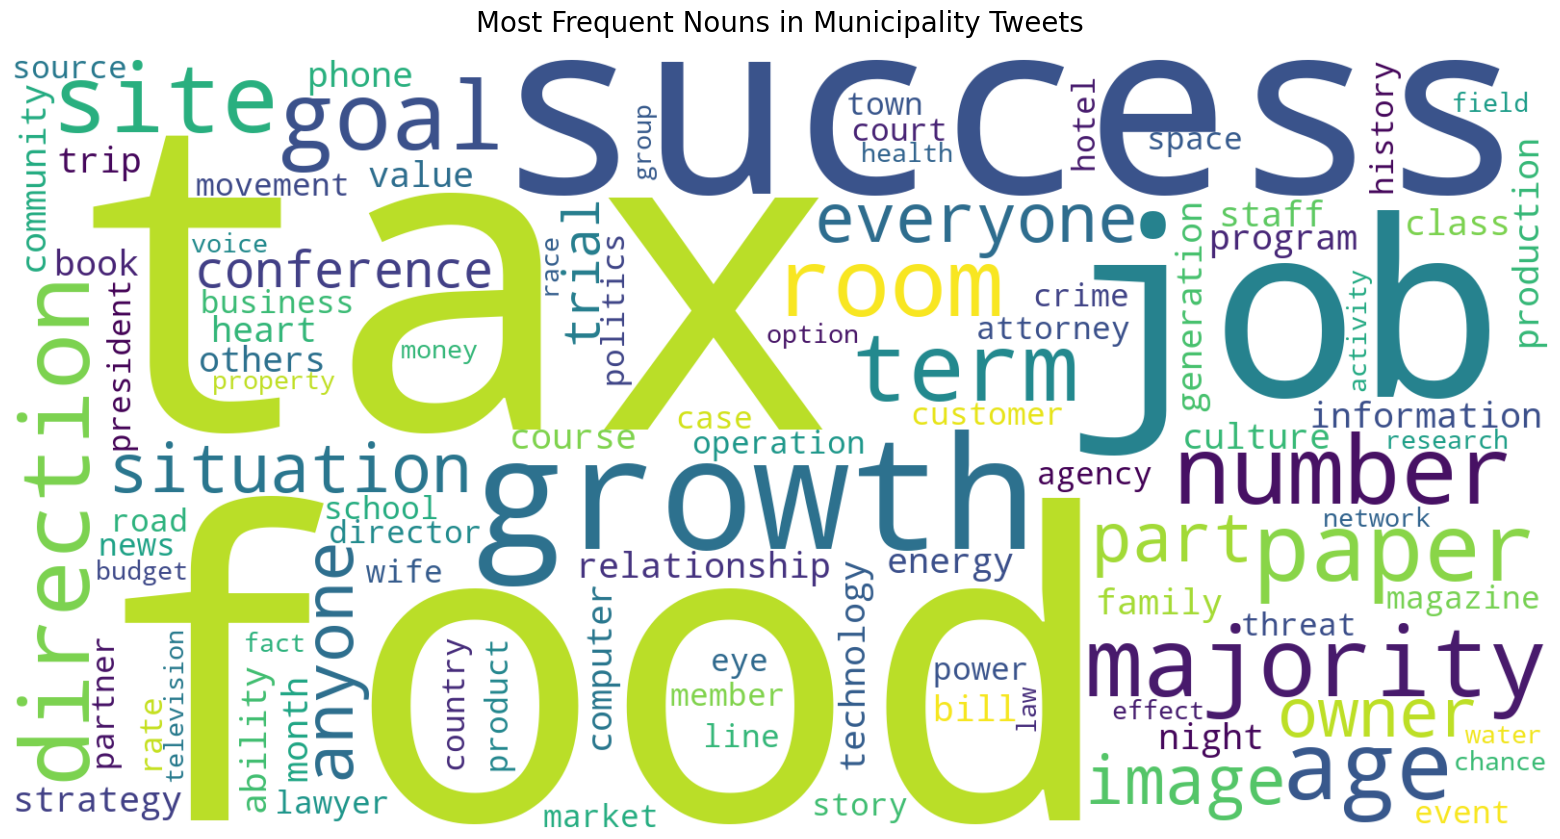

In [9]:
# 6. Visualization of contained words
# 1. Combine all cleaned tweets into one large string
all_text = " ".join(df['clean_text'])

# 2. Generate the Word Cloud
wordcloud = WordCloud(
    width=1600, 
    height=800, 
    background_color='white', 
    colormap='viridis',     
    max_words=100,           # Limits to the top 100 most important nouns
    contour_width=3, 
    contour_color='steelblue'
).generate(all_text)

# 3. Visualization
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Nouns in Municipality Tweets', fontsize=20, pad=20)
plt.show()

--- TOP 5 ACTIVE USERS ---
Username
pjohnson     6
nbrown       5
awilliams    5
nwhite       4
vbrown       4
Name: count, dtype: int64


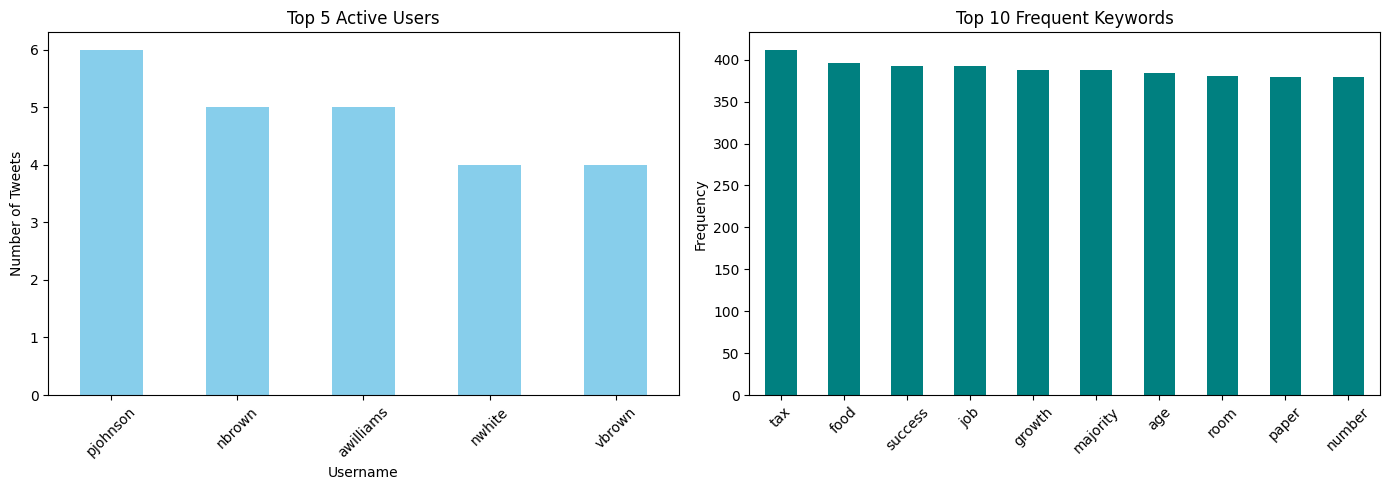

In [10]:
# 7. Entity Analysis
# Most active users ('username' is the column)
print("--- TOP 5 ACTIVE USERS ---")
top_users = df['Username'].value_counts().head(5)
print(top_users)

# Extract Keywords
all_words = [word for sublist in df['tokens'] for word in sublist]
top_words = pd.Series(all_words).value_counts().head(10)

# Visualization
plt.figure(figsize=(14, 5))

# Plot Active Users
plt.subplot(1, 2, 1)
top_users.plot(kind='bar', color='skyblue')
plt.title('Top 5 Active Users')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)

# Plot Top Keywords
plt.subplot(1, 2, 2)
top_words.plot(kind='bar', color='teal')
plt.title('Top 10 Frequent Keywords')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# 8. Vectorization: Using TF-IDF and Bag-of-Words

# TF-IDF Vectorization
tfidf_vec = TfidfVectorizer(max_features=1000, stop_words='english', max_df=0.3, min_df=10, ngram_range=(1,2)) #Initialize Vectorizer with TF-IDF
tfidf_matrix = tfidf_vec.fit_transform(df['clean_text']) #Create the Document-Term Matrix

# Bag-of-Words Vectorization (CountVectorizer)
bow_vec = CountVectorizer(max_features=1000, stop_words='english')
bow_matrix = bow_vec.fit_transform(df['clean_text'])

print(f"TF-IDF Shape: {tfidf_matrix.shape} | BoW Shape: {bow_matrix.shape}")

TF-IDF Shape: (10000, 625) | BoW Shape: (10000, 651)


In [12]:
# 9. Topic Extraction (LDA vs. LSA)
# LDA on BoW (Standard for LDA)
lda_bow = LatentDirichletAllocation(n_components=5, random_state=42)
lda_bow.fit(bow_matrix)

# LSA on TF-IDF (Standard for LSA)
lsa_tfidf = TruncatedSVD(n_components=5, random_state=42)
lsa_tfidf.fit(tfidf_matrix)

print("Models trained: LDA (BoW) and LSA (TF-IDF).")

Models trained: LDA (BoW) and LSA (TF-IDF).


In [13]:
# 10. Coherence Score Comparison
def get_coherence_score(model, tokenized_data, dictionary, feature_names):
    # Extract the top 10 words for each topic from the sklearn model
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-11:-1]
        topics.append([feature_names[i] for i in top_features_ind])
    
    # Calculate Coherence
    cm = CoherenceModel(topics=topics, 
                        texts=tokenized_data, 
                        dictionary=dictionary, 
                        coherence='c_v')
    return cm.get_coherence()

# Prepare Gensim Dictionary
gensim_dict = Dictionary(df['tokens'])

# Calculate Scores
score_lda = get_coherence_score(lda_bow, df['tokens'].tolist(), gensim_dict, bow_vec.get_feature_names_out())
score_lsa = get_coherence_score(lsa_tfidf, df['tokens'].tolist(), gensim_dict, tfidf_vec.get_feature_names_out())

# Comparison Table
results = pd.DataFrame({
    'Method': ['LDA (on BoW)', 'LSA (on TF-IDF)'],
    'Coherence Score': [score_lda, score_lsa]
})

print(results)

            Method  Coherence Score
0     LDA (on BoW)         0.330985
1  LSA (on TF-IDF)         0.339133


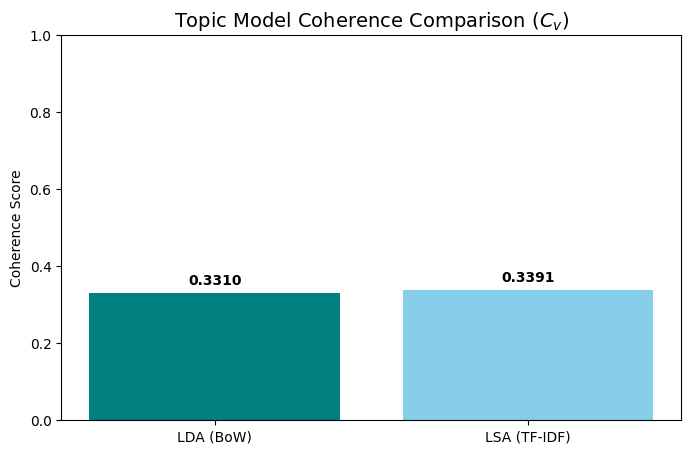

In [14]:
# 11. Visualize the results
# Data from your results dataframe
results = pd.DataFrame({
    'Method': ['LDA (BoW)', 'LSA (TF-IDF)'],
    'Coherence Score': [score_lda, score_lsa]
})

plt.figure(figsize=(8, 5))
plt.bar(results['Method'], results['Coherence Score'], color=['teal', 'skyblue'])
plt.title('Topic Model Coherence Comparison ($C_v$)', fontsize=14)
plt.ylabel('Coherence Score')
plt.ylim(0, 1)

# Add value labels on top of bars
for i, v in enumerate(results['Coherence Score']):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

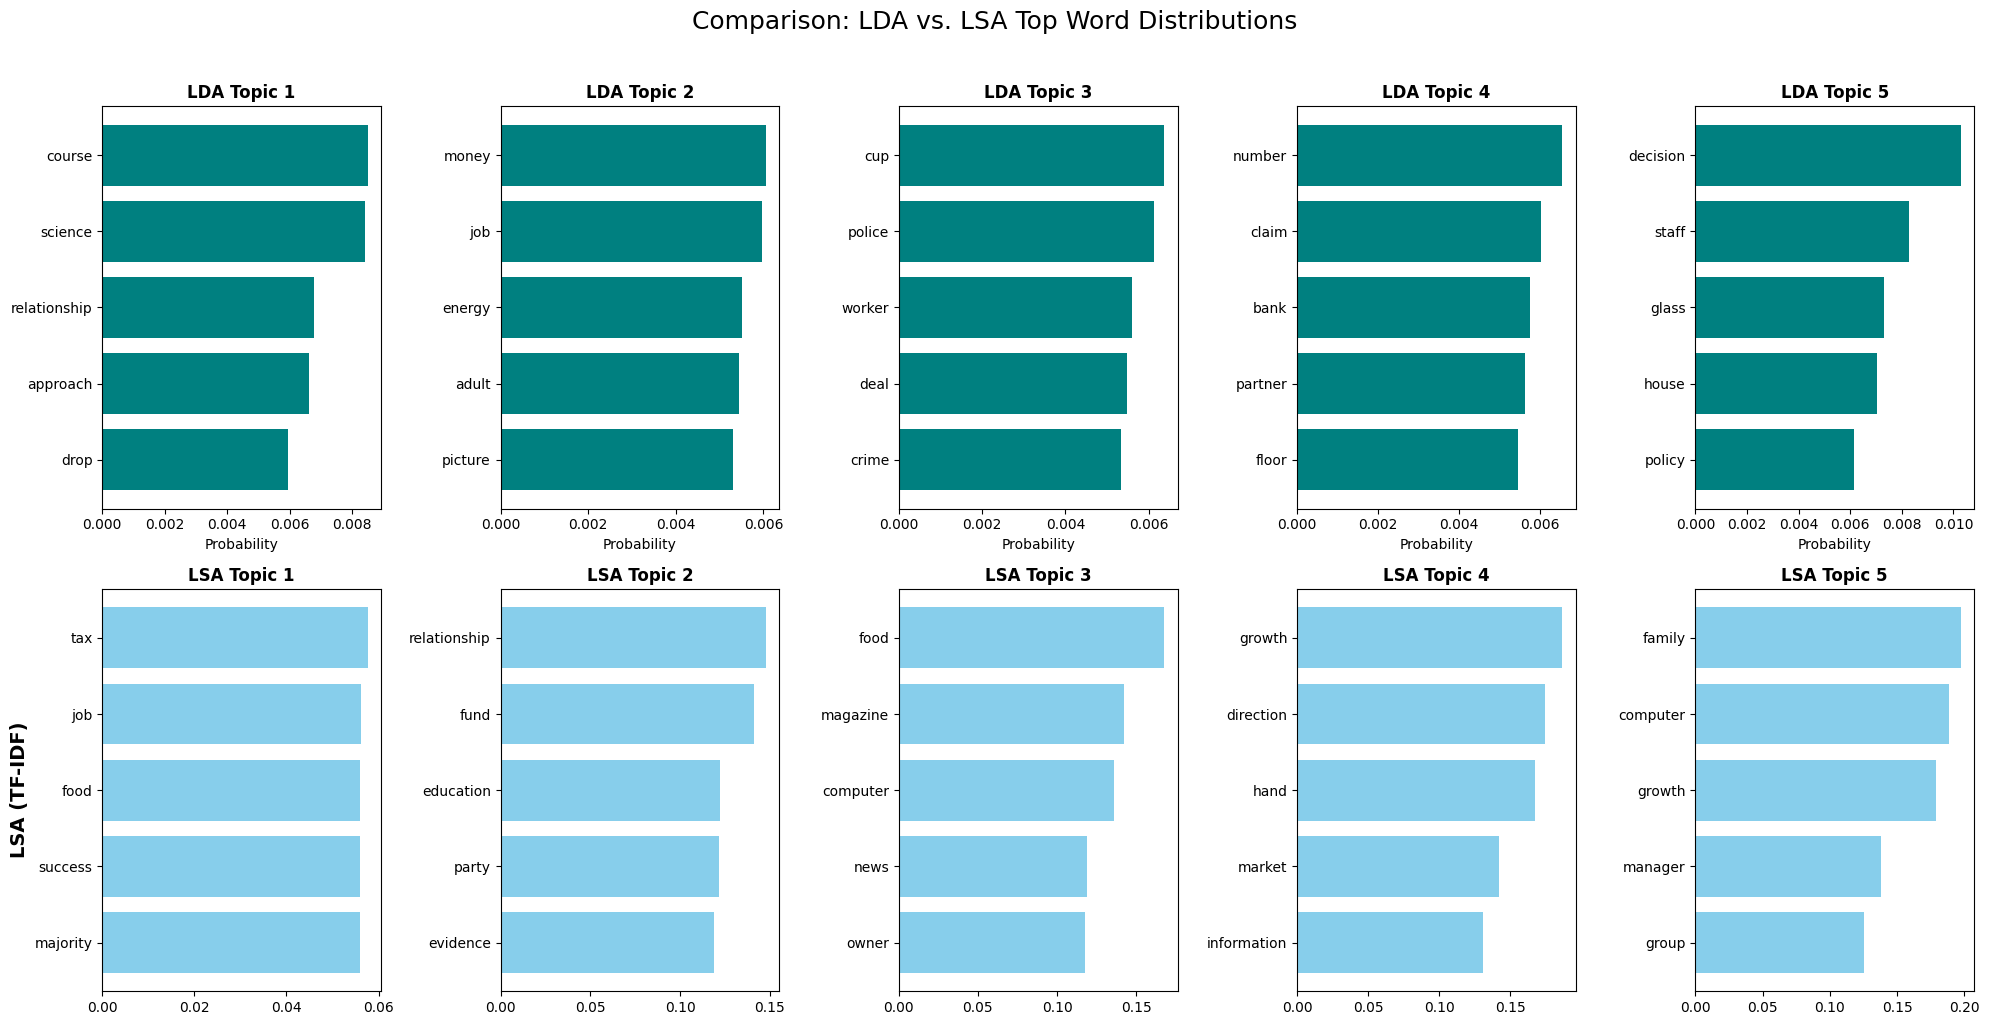

In [15]:
# 12. Visualize the Top Words per Topics
def plot_combined_topics(lda_model, lsa_model, lda_features, lsa_features, n_top_words=5):
    # Create a grid: 2 rows (LDA, LSA), 5 columns (Topics)
    fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharex=False)
    
    # 1. Plot LDA Topics (Top Row)
    for i, topic in enumerate(lda_model.components_):
        # Normalize the raw components into probabilities
        topic_probability = topic / topic.sum() 
    
        top_idx = topic_probability.argsort()[: -n_top_words - 1 : -1]
        features = [lda_features[j] for j in top_idx]
        weights = topic_probability[top_idx] # These will now be between 0 and 1
    
        ax = axes[0, i]
        ax.barh(features, weights, color='teal')
        ax.set_title(f'LDA Topic {i+1}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Probability')
        ax.invert_yaxis()


    # 2. Plot LSA Topics (Bottom Row)
    for i, topic in enumerate(lsa_model.components_):
        top_idx = topic.argsort()[: -n_top_words - 1 : -1]
        features = [lsa_features[j] for j in top_idx]
        weights = topic[top_idx]
        
        ax = axes[1, i]
        ax.barh(features, weights, color='skyblue')
        ax.set_title(f'LSA Topic {i+1}', fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        if i == 0: ax.set_ylabel('LSA (TF-IDF)', fontsize=14, fontweight='bold')

    plt.suptitle('Comparison: LDA vs. LSA Top Word Distributions', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

# Execute the comparison
plot_combined_topics(
    lda_bow, lsa_tfidf, 
    bow_vec.get_feature_names_out(), 
    tfidf_vec.get_feature_names_out()
)